# 서울시 자치구 4유형 분류 — 사업체 + 생활인구

서울시 25개 자치구를 다음 4가지 유형으로 분류한다.

- 🏠 **주거형** — 거주민 중심
- 🏢 **상업형** — 업무·오피스 중심
- 🚶 **유동집중형** — 관광·소비 유동 중심
- 🔀 **혼합형** — 어느 한쪽으로도 치우치지 않음

분류 근거: **사업체 변수 4개(B1~B4) + 생활인구 변수 3개(L1~L3) = 7개 변수**의 z-score 결합 규칙 + KMeans(k=4) 사이드 체크.

| 변수 | 정의 |
|---|---|
| B1 평균규모 | 총종사자/사업체수 |
| B2 오피스비 | (정보통신+금융보험+전문과학기술+부동산) 종사자/총종사자 |
| B3 소비관광비 | (도매소매+숙박음식+예술스포츠여가) 종사자/총종사자 |
| B4 생활밀착비 | (교육+보건복지+협회단체개인서비스) 종사자/총종사자 |
| L1 주야비 | 평일 14시 인구 / 평일 03시 인구 |
| L2 주말비 | 주말 14시 / 평일 14시 |
| L3 야간거주비 | 평일 03시 / 거주인구 |

**분류 규칙(우선순위 순서)**
1. 주거형: `L1 < +0.5σ` AND `B4 > +0.5σ`
2. 상업형: `B2 > +0.5σ` AND `B1 > +0.5σ` AND `L2 < -0.3σ`
3. 유동집중형: `B3 > +0.5σ` AND `L2 > 0σ`
4. 혼합형: 위 어디에도 해당 안 됨

산출물: `data/preprocess/gu_classified.csv` (자치구·거주인구·B1~B4·L1~L3·유형·kmeans_label)


## Step 0. 환경 셋업

라이브러리 임포트, 한글 폰트 설정, 자치구 코드 매핑 dict 정의, 분석 변수용 산업 그룹 정의.

### Step 0a. 의존성 자동 점검 (openpyxl)

Anaconda 일부 환경에 설치된 openpyxl < 3.1.0은 pandas 최신 버전과 호환되지 않아 `사업체현황_2024.xlsx` 로드 시 ImportError가 발생함. 이 셀이 자동으로 점검·업그레이드함.

**한 번만 실행하면 OK** — 이후 셀들에서는 평소처럼 `pd.read_excel(..., engine='openpyxl')` 사용 가능.

In [1]:
import sys, subprocess, importlib

def _ver_tuple(s):
    return tuple(int(x) for x in s.split(".")[:3] if x.isdigit())

def _purge_module(prefix):
    """sys.modules에서 해당 prefix로 시작하는 모든 항목 제거"""
    purged = [m for m in list(sys.modules) if m == prefix or m.startswith(prefix + ".")]
    for m in purged:
        del sys.modules[m]
    return purged

def ensure_openpyxl(min_ver="3.1.0"):
    # 1차: 현재 메모리 상 버전 확인
    try:
        import openpyxl
        cur = openpyxl.__version__
    except ImportError:
        cur = None

    if cur and _ver_tuple(cur) >= _ver_tuple(min_ver):
        print(f"✅ openpyxl {cur} (>= {min_ver}) — OK")
        return

    if cur:
        print(f"⚠ openpyxl {cur} < {min_ver} — 업그레이드 진행")
    else:
        print("⚠ openpyxl 미설치 — 설치 진행")
    cmd = [sys.executable, "-m", "pip", "install", "--upgrade",
           f"openpyxl>={min_ver}"]
    print("실행:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr[-800:])
        raise RuntimeError("pip install 실패 — 터미널에서 직접 실행하세요")
    print("pip 출력 (마지막 200자):", result.stdout[-200:].strip())

    # 3차: sys.modules 캐시 완전 제거
    _purge_module("openpyxl")
    _purge_module("pandas.io.excel._openpyxl")

    # 4차: 재임포트 후 검증
    import openpyxl
    new_ver = openpyxl.__version__
    if _ver_tuple(new_ver) < _ver_tuple(min_ver):
        raise RuntimeError(
            f"업그레이드 후에도 버전이 {new_ver}로 잡힘. "
            f"Jupyter 메뉴에서 [Kernel → Restart Kernel] 후 다시 실행하세요."
        )
    print(f"✅ 재로드 완료 — openpyxl {new_ver}")

ensure_openpyxl("3.1.0")

✅ openpyxl 3.1.5 (>= 3.1.0) — OK


In [2]:
import os, sys, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.unicode.east_asian_width", True)
pd.set_option("display.max_columns", 50)

# ─ 한글 폰트 (Windows 우선, 없으면 fallback)
for fname in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]:
    try:
        mpl.rcParams["font.family"] = fname
        break
    except Exception:
        pass
mpl.rcParams["axes.unicode_minus"] = False

# ─ 작업 디렉토리: notebook 위치(=notebooks/) 기준이므로 한 단계 위로 올라가서 data/ 접근
DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), "..", "data"))
PREPROC_DIR = os.path.join(DATA_DIR, "preprocess")
os.makedirs(PREPROC_DIR, exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("PREPROC_DIR:", PREPROC_DIR)

# ─ 자치구 법정동 코드(5자리) → 자치구명
GU_CODE_MAP = {
    11110: "종로구",   11140: "중구",     11170: "용산구",   11200: "성동구",
    11215: "광진구",   11230: "동대문구", 11260: "중랑구",   11290: "성북구",
    11305: "강북구",   11320: "도봉구",   11350: "노원구",   11380: "은평구",
    11410: "서대문구", 11440: "마포구",   11470: "양천구",   11500: "강서구",
    11530: "구로구",   11545: "금천구",   11560: "영등포구", 11590: "동작구",
    11620: "관악구",   11650: "서초구",   11680: "강남구",   11710: "송파구",
    11740: "강동구"
}

# ─ 산업 그룹 정의 (B2/B3/B4 산정용) — 사업체현황_2024.xlsx 컬럼 인덱스 기준
# 엑셀 cols 0~6: 자치구명/합계, cols 7~44: 산업 19종 × (사업체수, 종사자수) 페어
# 종사자수 컬럼 인덱스(0-based): 8,10,12,...,44
INDUSTRY_NAMES = [
    "농업 임업 및 어업", "광업", "제조업", "전기 가스 증기 및 공기조절 공급업",
    "수도 하수 및 폐기물 처리 원료 재생업", "건설업", "도매 및 소매업",
    "운수 및 창고업", "숙박 및 음식점업", "정보통신업", "금융 및 보험업",
    "부동산업", "전문 과학 및 기술 서비스업", "사업시설 관리 사업 지원 및 임대 서비스업",
    "공공행정 국방 및 사회보장 행정", "교육 서비스업", "보건업 및 사회복지 서비스업",
    "예술 스포츠 및 여가관련 서비스업", "협회 및 단체 수리 및 기타 개인 서비스업",
]

# B2 오피스비: 정보통신, 금융보험, 전문과학기술, 부동산
OFFICE_INDUSTRIES = ["정보통신업", "금융 및 보험업",
                     "전문 과학 및 기술 서비스업", "부동산업"]
# B3 소비관광비: 도매소매, 숙박음식, 예술스포츠여가
CONSUME_INDUSTRIES = ["도매 및 소매업", "숙박 및 음식점업",
                      "예술 스포츠 및 여가관련 서비스업"]
# B4 생활밀착비: 교육, 보건복지, 협회단체개인서비스
LIVING_INDUSTRIES = ["교육 서비스업", "보건업 및 사회복지 서비스업",
                     "협회 및 단체 수리 및 기타 개인 서비스업"]

print("산업 19종 정의 완료")
print("OFFICE:", OFFICE_INDUSTRIES)
print("CONSUME:", CONSUME_INDUSTRIES)
print("LIVING:", LIVING_INDUSTRIES)


DATA_DIR: d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data
PREPROC_DIR: d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess
산업 19종 정의 완료
OFFICE: ['정보통신업', '금융 및 보험업', '전문 과학 및 기술 서비스업', '부동산업']
CONSUME: ['도매 및 소매업', '숙박 및 음식점업', '예술 스포츠 및 여가관련 서비스업']
LIVING: ['교육 서비스업', '보건업 및 사회복지 서비스업', '협회 및 단체 수리 및 기타 개인 서비스업']


**검증 — Step 0**

In [3]:
import sklearn
print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("sklearn:", sklearn.__version__)
print()
print("=== data/ 폴더 파일 ===")
for f in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, f)
    if os.path.isfile(p):
        print(f"  {f:50s} ({os.path.getsize(p):>10,} B)")

# 필수 3개 파일 확인
required = {
    "사업체": "사업체현황_2024.xlsx",
    "생활인구": "생활인구_2024.csv",
}
missing = []
for label, name in required.items():
    p = os.path.join(DATA_DIR, name)
    print(f"\n[{label}] {name}: {'OK' if os.path.exists(p) else '❌ NOT FOUND'}")
    if not os.path.exists(p):
        missing.append(name)
# 거주인구 csv는 glob
pop_files = glob.glob(os.path.join(DATA_DIR, "주민*1인당*배출량*.csv"))
print(f"\n[거주인구] glob 매치: {pop_files}")
assert pop_files, "주민+1인당+...csv 못 찾음"
assert not missing, f"필수 파일 누락: {missing}"
print("\n✅ 필수 파일 모두 존재")


pandas: 2.2.3
numpy : 1.26.4
sklearn: 1.2.2

=== data/ 폴더 파일 ===
  사업체현황_2024.xlsx                                    (    13,289 B)
  생활계폐기물+발생량+및+처리현황(2020년+이후)_20260325111941.csv     (     5,561 B)
  생활인구_2024.csv                                      (75,100,851 B)
  쓰레기수거+현황(2020년+이후)_20260325105044.csv              (    11,008 B)
  음식물류+폐기물+발생원별+발생량_20260325105203.csv               (     8,691 B)
  주민+1인당+생활계폐기물(쓰레기)+배출량_20260325104957.csv          (     2,783 B)
  폐기물+재활용+현황(2020년+이후)_20260325105123.csv            (     9,083 B)

[사업체] 사업체현황_2024.xlsx: OK

[생활인구] 생활인구_2024.csv: OK

[거주인구] glob 매치: ['d:\\바탕화면\\BAF\\환경_대시보드\\seoul-bigdata\\data\\주민+1인당+생활계폐기물(쓰레기)+배출량_20260325104957.csv']

✅ 필수 파일 모두 존재


## Step 1. 사업체현황 로드

`data/사업체현황_2024.xlsx`의 **데이터** 시트를 5행 멀티헤더로 읽어, 자치구명·합계·산업 19종(사업체수·종사자수 페어)이 들어간 (25, 45) 테이블을 만든다.

- 6행(인덱스 5)은 "합계/소계" = 서울시 전체 → 제외
- 7~31행이 25개 자치구
- "-" 값은 NaN으로 변환 후 숫자형 캐스팅


In [4]:
path_biz = os.path.join(DATA_DIR, "사업체현황_2024.xlsx")

def _read_biz_excel(path):
    """openpyxl 우선, 실패 시 calamine 폴백, 둘 다 안 되면 명확한 안내"""
    try:
        import openpyxl
        cur = openpyxl.__version__
        ver = tuple(int(x) for x in cur.split(".")[:3] if x.isdigit())
        if ver < (3, 1, 0):
            raise RuntimeError(
                f"⚠ 메모리에 캐시된 openpyxl {cur}이 너무 낮음 (3.1.0+ 필요). "
                "→ Jupyter 메뉴 [Kernel → Restart Kernel] 후 노트북을 처음부터 다시 실행하세요."
            )
    except ImportError:
        pass

    last_err = None
    for engine in ("openpyxl", "calamine"):
        try:
            return pd.read_excel(path, sheet_name="데이터", skiprows=5,
                                 header=None, engine=engine)
        except ImportError as e:
            print(f"⚠ engine={engine} 실패: {str(e)[:80]}")
            last_err = e
            continue
    raise RuntimeError(
        "엑셀 로드 실패 — 해결: ① [Kernel → Restart Kernel] 후 노트북 처음부터 다시 실행 "
        "(권장) ② 터미널에서 pip install --upgrade openpyxl 실행 후 커널 재시작. "
        f"마지막 에러: {last_err}"
    )

df_biz_raw = _read_biz_excel(path_biz)
print("raw shape:", df_biz_raw.shape)

# 컬럼명 직접 부여 (총 45개)
cols = ["동별1", "자치구",
        "사업체수_총_소계", "사업체수_총_여성",
        "종사자수_총_소계", "종사자수_총_남", "종사자수_총_여"]
for ind in INDUSTRY_NAMES:
    cols.append(f"사업체수_{ind}")
    cols.append(f"종사자수_{ind}")
assert len(cols) == 45, f"컬럼 정의 오류: {len(cols)} != 45"
df_biz_raw.columns = cols
print("컬럼 부여 완료. 첫 3행:")
print(df_biz_raw[["동별1", "자치구", "사업체수_총_소계",
                  "종사자수_총_소계"]].head(3))

# 첫 행은 "합계 / 소계" — 서울시 전체 → 제외
seoul_total_row = df_biz_raw.iloc[0]
print(f"[제외할 합계행] 동별1={seoul_total_row[chr(0x44d4)+chr(0x48c4)+chr(0x48c4)] if False else seoul_total_row['동별1']!r}")
df_biz = df_biz_raw.iloc[1:].copy().reset_index(drop=True)

# "-" → NaN, 숫자형 캐스팅
def to_numeric_safe(s):
    return pd.to_numeric(s.replace("-", np.nan), errors="coerce")

for c in df_biz.columns:
    if c not in ("동별1", "자치구"):
        df_biz[c] = to_numeric_safe(df_biz[c])

print("정제 완료 — shape:", df_biz.shape)
df_biz.head(3)

raw shape: (26, 45)
컬럼 부여 완료. 첫 3행:
  동별1  자치구  사업체수_총_소계  종사자수_총_소계
0  합계    소계           1176066           5772456
1   NaN  종로구             46830            265635
2   NaN    중구             67098            399960
[제외할 합계행] 동별1='합계'
정제 완료 — shape: (25, 45)


,동별1,자치구,사업체수_총_소계,사업체수_총_여성,종사자수_총_소계,종사자수_총_남,종사자수_총_여,사업체수_농업 임업 및 어업,종사자수_농업 임업 및 어업,사업체수_광업,종사자수_광업,사업체수_제조업,종사자수_제조업,사업체수_전기 가스 증기 및 공기조절 공급업,종사자수_전기 가스 증기 및 공기조절 공급업,사업체수_수도 하수 및 폐기물 처리 원료 재생업,종사자수_수도 하수 및 폐기물 처리 원료 재생업,사업체수_건설업,종사자수_건설업,사업체수_도매 및 소매업,종사자수_도매 및 소매업,사업체수_운수 및 창고업,종사자수_운수 및 창고업,사업체수_숙박 및 음식점업,종사자수_숙박 및 음식점업,사업체수_정보통신업,종사자수_정보통신업,사업체수_금융 및 보험업,종사자수_금융 및 보험업,사업체수_부동산업,종사자수_부동산업,사업체수_전문 과학 및 기술 서비스업,종사자수_전문 과학 및 기술 서비스업,사업체수_사업시설 관리 사업 지원 및 임대 서비스업,종사자수_사업시설 관리 사업 지원 및 임대 서비스업,사업체수_공공행정 국방 및 사회보장 행정,종사자수_공공행정 국방 및 사회보장 행정,사업체수_교육 서비스업,종사자수_교육 서비스업,사업체수_보건업 및 사회복지 서비스업,종사자수_보건업 및 사회복지 서비스업,사업체수_예술 스포츠 및 여가관련 서비스업,종사자수_예술 스포츠 및 여가관련 서비스업,사업체수_협회 및 단체 수리 및 기타 개인 서비스업,종사자수_협회 및 단체 수리 및 기타 개인 서비스업
0,NaN,종로구,46830,16243,265635,141230,124405,6.0,21.0,2.0,75.0,4751,11449,68,234,10,86,605,13520,17372,40778,2112,9861,6928,24734,1470,18493,1080,24230,2459,7311,2685,31676,1358,18329,92,16571,1089,13926,840,19792,1178,6260,2725,8289
1,NaN,중구,67098,25163,399960,219382,180578,NaN,NaN,1.0,4.0,8992,23546,27,590,20,408,584,6923,30756,76226,2318,16167,6650,31115,1631,32208,2966,64542,3085,11578,3711,55840,1767,34457,68,13156,715,9523,851,12399,709,3408,2247,7870
2,NaN,용산구,27854,10279,157564,86079,71485,2.0,2.0,NaN,NaN,1013,2792,19,55,24,326,691,6147,9163,33134,1515,3933,4886,17620,1188,13231,583,6563,1928,4669,1980,24575,601,12711,50,5903,952,7616,627,7908,701,3543,1931,6836


**검증 — Step 1**

In [5]:
print("shape (예상 (25, 45)):", df_biz.shape)
print()
print("자치구 25개:", df_biz["자치구"].tolist())
print()
print("dtypes (산업 컬럼 일부 발췌):")
print(df_biz[["자치구", "종사자수_총_소계",
              "종사자수_도매 및 소매업",
              "종사자수_숙박 및 음식점업"]].dtypes)
print()
print("결측치 합계:", df_biz.isna().sum().sum())
total_employee = df_biz["종사자수_총_소계"].sum()
print(f"\n종사자수 합계: {total_employee:,}명")
print(f"기대치(서울시 전체 5,772,456명) 대비: "
      f"{total_employee/5_772_456*100:.1f}%")
assert df_biz.shape == (25, 45)
assert df_biz["자치구"].nunique() == 25
print("\n✅ Step 1 검증 통과")
df_biz.head()


shape (예상 (25, 45)): (25, 45)

자치구 25개: ['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구', '도봉구', '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구', '관악구', '서초구', '강남구', '송파구', '강동구']

dtypes (산업 컬럼 일부 발췌):
자치구                       object
종사자수_총_소계              int64
종사자수_도매 및 소매업       int64
종사자수_숙박 및 음식점업     int64
dtype: object

결측치 합계: 69

종사자수 합계: 5,772,456명
기대치(서울시 전체 5,772,456명) 대비: 100.0%

✅ Step 1 검증 통과


,동별1,자치구,사업체수_총_소계,사업체수_총_여성,종사자수_총_소계,종사자수_총_남,종사자수_총_여,사업체수_농업 임업 및 어업,종사자수_농업 임업 및 어업,사업체수_광업,종사자수_광업,사업체수_제조업,종사자수_제조업,사업체수_전기 가스 증기 및 공기조절 공급업,종사자수_전기 가스 증기 및 공기조절 공급업,사업체수_수도 하수 및 폐기물 처리 원료 재생업,종사자수_수도 하수 및 폐기물 처리 원료 재생업,사업체수_건설업,종사자수_건설업,사업체수_도매 및 소매업,종사자수_도매 및 소매업,사업체수_운수 및 창고업,종사자수_운수 및 창고업,사업체수_숙박 및 음식점업,종사자수_숙박 및 음식점업,사업체수_정보통신업,종사자수_정보통신업,사업체수_금융 및 보험업,종사자수_금융 및 보험업,사업체수_부동산업,종사자수_부동산업,사업체수_전문 과학 및 기술 서비스업,종사자수_전문 과학 및 기술 서비스업,사업체수_사업시설 관리 사업 지원 및 임대 서비스업,종사자수_사업시설 관리 사업 지원 및 임대 서비스업,사업체수_공공행정 국방 및 사회보장 행정,종사자수_공공행정 국방 및 사회보장 행정,사업체수_교육 서비스업,종사자수_교육 서비스업,사업체수_보건업 및 사회복지 서비스업,종사자수_보건업 및 사회복지 서비스업,사업체수_예술 스포츠 및 여가관련 서비스업,종사자수_예술 스포츠 및 여가관련 서비스업,사업체수_협회 및 단체 수리 및 기타 개인 서비스업,종사자수_협회 및 단체 수리 및 기타 개인 서비스업
0,NaN,종로구,46830,16243,265635,141230,124405,6.0,21.0,2.0,75.0,4751,11449,68,234,10,86,605,13520,17372,40778,2112,9861,6928,24734,1470,18493,1080,24230,2459,7311,2685,31676,1358,18329,92,16571,1089,13926,840,19792,1178,6260,2725,8289
1,NaN,중구,67098,25163,399960,219382,180578,NaN,NaN,1.0,4.0,8992,23546,27,590,20,408,584,6923,30756,76226,2318,16167,6650,31115,1631,32208,2966,64542,3085,11578,3711,55840,1767,34457,68,13156,715,9523,851,12399,709,3408,2247,7870
2,NaN,용산구,27854,10279,157564,86079,71485,2.0,2.0,NaN,NaN,1013,2792,19,55,24,326,691,6147,9163,33134,1515,3933,4886,17620,1188,13231,583,6563,1928,4669,1980,24575,601,12711,50,5903,952,7616,627,7908,701,3543,1931,6836
3,NaN,성동구,39264,13180,201023,111482,89541,2.0,3.0,NaN,NaN,4003,23315,37,443,35,799,1668,8748,10913,36826,3363,8162,4505,13899,2150,20787,469,4086,2283,6004,3316,22237,796,17471,45,5041,1413,11102,871,11296,840,2933,2555,7871
4,NaN,광진구,33295,12450,125475,66236,59239,2.0,6.0,NaN,NaN,1739,5555,23,25,23,323,1479,11117,8942,19162,3286,5806,5013,14518,1080,4326,260,2690,2056,4083,1720,6969,833,8855,40,3969,1551,15113,1012,13951,1210,3735,3026,5272


## Step 2. 거주인구 추출

`data/주민+1인당+생활계폐기물(쓰레기)+배출량_*.csv` (CP949)에서 자치구명과 2024년 주민수 컬럼만 추출.

- 컬럼 13개: V1(자치구) + 4년 × 3변수(1인당/발생량/주민수) = 13
- 2024년 주민수는 **마지막 컬럼(인덱스 12)**
- "계/합계/소계/서울시" 합계행 제외


In [6]:
# 정확한 파일명을 glob로
pop_files = glob.glob(os.path.join(DATA_DIR, "주민*1인당*배출량*.csv"))
assert len(pop_files) == 1, f"파일 개수 이상: {pop_files}"
path_pop = pop_files[0]
print("거주인구 파일:", os.path.basename(path_pop))

# 헤더 2줄 스킵 (멀티헤더), 데이터부터 읽기
# (인코딩은 UTF-8/CP949 둘 다 시도)
def _read_pop_csv(p):
    for enc in ("utf-8", "utf-8-sig", "cp949", "euc-kr"):
        try:
            return pd.read_csv(p, encoding=enc, header=None, skiprows=2)
        except (UnicodeDecodeError, UnicodeError):
            continue
    raise IOError(f"인코딩 자동감지 실패: {p}")
df_pop_raw = _read_pop_csv(path_pop)
print("raw shape:", df_pop_raw.shape, "(예상: 26행 또는 27행)")
print(df_pop_raw.head(3))

# 13개 컬럼 가정: V1=자치구, V13(인덱스 12)=2024년 주민수
SUMMARY_KEYWORDS = {"계", "합계", "소계", "서울시"}
gu_names = df_pop_raw.iloc[:, 0].astype(str).str.strip()
mask = ~gu_names.isin(SUMMARY_KEYWORDS)
pop_df = pd.DataFrame({
    "자치구": gu_names[mask].values,
    "거주인구": pd.to_numeric(df_pop_raw.iloc[:, 12][mask], errors="coerce")
                  .astype("Int64").values,
})
pop_df = pop_df.dropna(subset=["거주인구"]).reset_index(drop=True)
print("\n✅ 추출 결과 shape:", pop_df.shape)
pop_df


거주인구 파일: 주민+1인당+생활계폐기물(쓰레기)+배출량_20260325104957.csv
raw shape: (26, 13) (예상: 26행 또는 27행)
       0     1        2        3     4        5        6     7        8   \
0      계  1.11  10852.9  9736027  1.13  10913.8  9667669  1.08  10426.9   
1  종로구  1.49    229.8   153789  1.88    285.9   152211  1.77    266.9   
2    중구  2.26    298.1   131787  2.49    325.4   130785  2.75    363.0   

        9     10       11       12  
0  9638799  1.09  10483.5  9597372  
1   150453  1.81    270.2   149608  
2   131793  2.78    365.0   131214  

✅ 추출 결과 shape: (25, 2)


,자치구,거주인구
0,종로구,149608
1,중구,131214
2,용산구,217194
3,성동구,281289
4,광진구,348652
5,동대문구,358603
6,중랑구,385349
7,성북구,435037
8,강북구,289374
9,도봉구,306032


**검증 — Step 2**

In [7]:
print("shape (예상 (25, 2)):", pop_df.shape)
print()
print("자치구 25개:", pop_df["자치구"].tolist())
print()
total_pop = int(pop_df["거주인구"].sum())
print(f"거주인구 합계: {total_pop:,}명 "
      f"(서울시 9,597,372명 ±1% 기대)")
assert pop_df.shape[0] == 25
assert 9_400_000 <= total_pop <= 9_700_000, \
    f"합계 이상치: {total_pop:,}"
# Step 1과 자치구 집합 일치 확인
biz_set = set(df_biz["자치구"])
pop_set = set(pop_df["자치구"])
print(f"\n사업체 ∩ 거주인구 자치구: {len(biz_set & pop_set)}개")
assert biz_set == pop_set, f"불일치: {biz_set ^ pop_set}"
print("\n✅ Step 2 검증 통과")
pop_df.head()


shape (예상 (25, 2)): (25, 2)

자치구 25개: ['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구', '도봉구', '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구', '관악구', '서초구', '강남구', '송파구', '강동구']

거주인구 합계: 9,597,372명 (서울시 9,597,372명 ±1% 기대)

사업체 ∩ 거주인구 자치구: 25개

✅ Step 2 검증 통과


,자치구,거주인구
0,종로구,149608
1,중구,131214
2,용산구,217194
3,성동구,281289
4,광진구,348652


## Step 3. ㅡ사업체 변수 4개 산출 (B1~B4)

| 변수 | 공식 |
|---|---|
| B1 평균규모 | 총종사자수 / 사업체수 |
| B2 오피스비 | (정보통신+금융보험+전문과학기술+부동산) 종사자 / 총종사자 |
| B3 소비관광비 | (도매소매+숙박음식+예술스포츠여가) 종사자 / 총종사자 |
| B4 생활밀착비 | (교육+보건복지+협회단체개인서비스) 종사자 / 총종사자 |

B2~B4의 분자 산업은 서로 겹치지 않음 → B2+B3+B4 ≤ 1 검증.

In [8]:
def industry_share(df, target_industries):
    """target_industries 종사자수 합 / 총종사자수"""
    cols = [f"종사자수_{ind}" for ind in target_industries]
    num = df[cols].fillna(0).sum(axis=1)
    den = df["종사자수_총_소계"].replace(0, np.nan)
    return (num / den).astype(float)

biz_var = pd.DataFrame({"자치구": df_biz["자치구"]})
biz_var["B1_평균규모"] = (df_biz["종사자수_총_소계"]
                       / df_biz["사업체수_총_소계"].replace(0, np.nan)).astype(float)
biz_var["B2_오피스비"]   = industry_share(df_biz, OFFICE_INDUSTRIES)
biz_var["B3_소비관광비"] = industry_share(df_biz, CONSUME_INDUSTRIES)
biz_var["B4_생활밀착비"] = industry_share(df_biz, LIVING_INDUSTRIES)

# 결측치 검사 — 본 데이터에선 없어야 함
assert biz_var.drop(columns=["자치구"]).isna().sum().sum() == 0, \
    "B1~B4 계산 중 NaN 발생"
biz_var


,자치구,B1_평균규모,B2_오피스비,B3_소비관광비,B4_생활밀착비
0,종로구,5.672325,0.307603,0.270190,0.158138
1,중구,5.960833,0.410461,0.276900,0.074487
2,용산구,5.656782,0.311226,0.344603,0.141911
3,성동구,5.119779,0.264219,0.266925,0.150575
4,광진구,3.768584,0.143997,0.298187,0.273648
5,동대문구,3.378678,0.124829,0.317755,0.284616
6,중랑구,2.727116,0.076985,0.272712,0.268140
7,성북구,3.531200,0.122407,0.262859,0.367205
8,강북구,2.953737,0.107578,0.302779,0.294023
9,도봉구,3.165744,0.118359,0.249941,0.315619


**검증 — Step 3**

=== B1~B4 describe ===
       B1_평균규모  B2_오피스비  B3_소비관광비  B4_생활밀착비
count       25.000       25.000         25.000         25.000
mean         4.512        0.222          0.265          0.232
std          1.304        0.108          0.035          0.100
min          2.727        0.077          0.188          0.074
25%          3.431        0.122          0.250          0.149
50%          4.121        0.211          0.264          0.258
75%          5.511        0.311          0.288          0.325
max          7.466        0.410          0.345          0.383

=== B2+B3+B4 분포 (1 미만이어야) ===
count    25.000
mean      0.719
std       0.051
min       0.618
25%       0.684
50%       0.716
75%       0.761
max       0.799
dtype: float64

=== B2 오피스비 TOP 5 (강남·서초·중구·종로·영등포 기대) ===
자치구
중구        0.410
강남구      0.385
영등포구    0.383
금천구      0.361
서초구      0.336
Name: B2_오피스비, dtype: float64

=== B3 소비관광비 TOP 5 (종로·중구·마포·강남 기대) ===
자치구
용산구      0.345
동대문구    0.318
강북구      0.303
은평구      0.298
광진구   

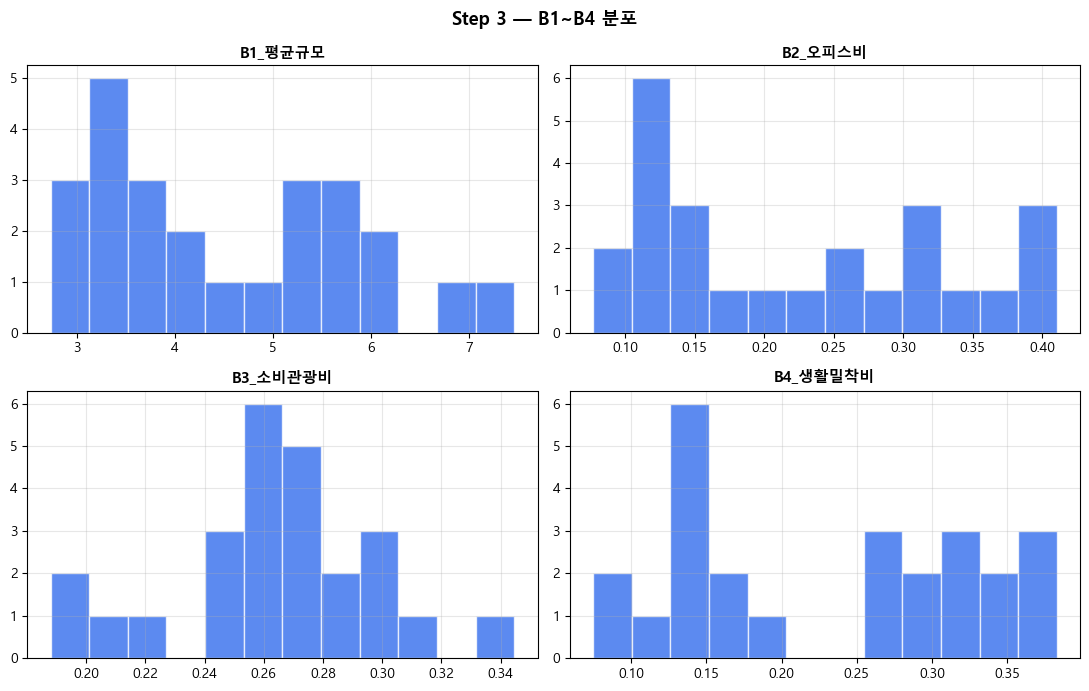


✅ Step 3 검증 통과


In [9]:
print("=== B1~B4 describe ===")
print(biz_var.drop(columns=["자치구"]).describe().round(3))
print()

# 비중 합 검증 (B2+B3+B4 < 1 이어야 함, 나머지는 제조·건설·운수 등)
share_sum = biz_var[["B2_오피스비", "B3_소비관광비", "B4_생활밀착비"]].sum(axis=1)
print("=== B2+B3+B4 분포 (1 미만이어야) ===")
print(share_sum.describe().round(3))
assert share_sum.max() < 1.0, "비중 합이 1 초과 — 산업 그룹 중복 의심"

# B1 양수
assert (biz_var["B1_평균규모"] > 0).all()

# 직관 검증
biz_var_idx = biz_var.set_index("자치구")
print()
print("=== B2 오피스비 TOP 5 (강남·서초·중구·종로·영등포 기대) ===")
print(biz_var_idx["B2_오피스비"].nlargest(5).round(3))
print()
print("=== B3 소비관광비 TOP 5 (종로·중구·마포·강남 기대) ===")
print(biz_var_idx["B3_소비관광비"].nlargest(5).round(3))
print()
print("=== B4 생활밀착비 TOP 5 (노원·도봉·강북·중랑 기대) ===")
print(biz_var_idx["B4_생활밀착비"].nlargest(5).round(3))

# 히스토그램 4분할
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.flatten(), ["B1_평균규모", "B2_오피스비",
                                    "B3_소비관광비", "B4_생활밀착비"]):
    ax.hist(biz_var[c], bins=12, color="#2563eb", alpha=0.75, edgecolor="white")
    ax.set_title(c, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)
plt.suptitle("Step 3 — B1~B4 분포", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n✅ Step 3 검증 통과")


## Step 4. 생활인구 데이터 로드 + 자치구 매핑

`data/생활인구_2024.csv` (UTF-8 with BOM, ~219,600행).

- `adstrd_code_se`(법정동코드 5자리) → `자치구명` 매핑
- `stdr_de_id`(YYYYMMDD) → 날짜 변환 → 요일·평일/주말 플래그
- 메모리 절약 위해 필요한 컬럼만 로드: stdr_de_id, tmzon_pd_se, adstrd_code_se, tot_lvpop_co


In [10]:
path_lvpop = os.path.join(DATA_DIR, "생활인구_2024.csv")

# 메모리 절약: 4개 컬럼만 로드
USE_COLS = ["stdr_de_id", "tmzon_pd_se", "adstrd_code_se", "tot_lvpop_co"]
df_lv = pd.read_csv(path_lvpop, encoding="utf-8-sig",
                    usecols=USE_COLS,
                    dtype={"stdr_de_id": np.int32,
                           "tmzon_pd_se": np.int8,
                           "adstrd_code_se": np.int32,
                           "tot_lvpop_co": np.float32})
print("raw shape:", df_lv.shape)
print(df_lv.head(3))

# 자치구 매핑
df_lv["자치구"] = df_lv["adstrd_code_se"].map(GU_CODE_MAP)
n_unmapped = df_lv["자치구"].isna().sum()
print(f"\n매핑 안 된 행: {n_unmapped:,}")
assert n_unmapped == 0, "GU_CODE_MAP에서 매핑 안 된 코드 존재"

# 날짜·요일 컬럼
df_lv["날짜"] = pd.to_datetime(df_lv["stdr_de_id"], format="%Y%m%d")
df_lv["요일"] = df_lv["날짜"].dt.dayofweek  # 0=월 ~ 6=일
df_lv["is_weekend"] = df_lv["요일"].isin([5, 6])

print(f"\n✅ 로드 완료 — shape: {df_lv.shape}")
df_lv.head(3)


raw shape: (219600, 4)
   stdr_de_id  tmzon_pd_se  adstrd_code_se   tot_lvpop_co
0    20240101            0           11110  231940.906250
1    20240101            0           11140  182354.546875
2    20240101            0           11170  255885.546875

매핑 안 된 행: 0

✅ 로드 완료 — shape: (219600, 8)


,stdr_de_id,tmzon_pd_se,adstrd_code_se,tot_lvpop_co,자치구,날짜,요일,is_weekend
0,20240101,0,11110,231940.906250,종로구,2024-01-01,0,False
1,20240101,0,11140,182354.546875,중구,2024-01-01,0,False
2,20240101,0,11170,255885.546875,용산구,2024-01-01,0,False


**검증 — Step 4**

In [11]:
print("총 행수:", f"{len(df_lv):,}", "(예상 219,600 = 366일×24h×25구)")
print("자치구 nunique:", df_lv["자치구"].nunique())
print("날짜 범위:", df_lv["날짜"].min().date(), "~",
      df_lv["날짜"].max().date())
print()
gu_counts = df_lv["자치구"].value_counts()
print("=== 자치구별 행 수 (균형 확인) ===")
print(f"min: {gu_counts.min():,}, max: {gu_counts.max():,}, "
      f"평균: {gu_counts.mean():,.0f}")
assert gu_counts.min() == gu_counts.max(), "자치구별 행 수 불균형"

print()
weekday_pct = (~df_lv["is_weekend"]).mean() * 100
weekend_pct = df_lv["is_weekend"].mean() * 100
print(f"평일 비율: {weekday_pct:.1f}% (예상 ~71%)")
print(f"주말 비율: {weekend_pct:.1f}% (예상 ~29%)")
assert df_lv["자치구"].nunique() == 25
print("\n✅ Step 4 검증 통과")


총 행수: 219,600 (예상 219,600 = 366일×24h×25구)
자치구 nunique: 25
날짜 범위: 2024-01-01 ~ 2024-12-31

=== 자치구별 행 수 (균형 확인) ===
min: 8,784, max: 8,784, 평균: 8,784

평일 비율: 71.6% (예상 ~71%)
주말 비율: 28.4% (예상 ~29%)

✅ Step 4 검증 통과


## Step 5. 생활인구 변수 3개 산출 (L1~L3)

자치구별로 다음 3가지 시간대 평균 인구를 산출:
- **평일 14시 평균** (월~금, hour=14)
- **평일 03시 평균** (월~금, hour=3)
- **주말 14시 평균** (토~일, hour=14)

| 변수 | 공식 | 의미 |
|---|---|---|
| L1 주야비 | 평일14시 ÷ 평일03시 | 통근형 시그널 (>1.5: 주간유입) |
| L2 주말비 | 주말14시 ÷ 평일14시 | 주말 활성도 (>1.0: 유동집중, <0.85: 상업) |
| L3 야간거주비 | 평일03시 ÷ 거주인구 | 진짜 거주자 비중 |


In [12]:
# 시간대별 자치구 평균
def gu_mean(df_subset):
    return df_subset.groupby("자치구")["tot_lvpop_co"].mean()

mask_wd_14 = (~df_lv["is_weekend"]) & (df_lv["tmzon_pd_se"] == 14)
mask_wd_03 = (~df_lv["is_weekend"]) & (df_lv["tmzon_pd_se"] == 3)
mask_we_14 = (df_lv["is_weekend"]) & (df_lv["tmzon_pd_se"] == 14)

평일14 = gu_mean(df_lv[mask_wd_14]).rename("평일14시")
평일03 = gu_mean(df_lv[mask_wd_03]).rename("평일03시")
주말14 = gu_mean(df_lv[mask_we_14]).rename("주말14시")

lv_var = pd.concat([평일14, 평일03, 주말14], axis=1).reset_index()

# 거주인구 머지 (Step 2)
lv_var = lv_var.merge(pop_df, on="자치구", how="left")
assert lv_var["거주인구"].notna().all(), "거주인구 머지 실패"

# L1, L2, L3 산출
lv_var["L1_주야비"]    = lv_var["평일14시"] / lv_var["평일03시"]
lv_var["L2_주말비"]    = lv_var["주말14시"] / lv_var["평일14시"]
lv_var["L3_야간거주비"] = lv_var["평일03시"] / lv_var["거주인구"]

assert lv_var[["L1_주야비", "L2_주말비", "L3_야간거주비"]].isna().sum().sum() == 0
lv_var.round(3)


,자치구,평일14시,평일03시,주말14시,거주인구,L1_주야비,L2_주말비,L3_야간거주비
0,강남구,1.083110e+06,672006.625000,808519.87500,563215,1.612,0.746,1.193
1,강동구,4.588694e+05,539500.187500,477472.06250,481474,0.851,1.041,1.121
2,강북구,2.388053e+05,289933.937500,259969.90625,289374,0.824,1.089,1.002
3,강서구,5.222511e+05,547354.937500,514501.50000,562194,0.954,0.985,0.974
4,관악구,3.889286e+05,499732.875000,424786.03125,495620,0.778,1.092,1.008
5,광진구,3.348001e+05,365865.468750,355035.68750,348652,0.915,1.060,1.049
6,구로구,3.760930e+05,390475.812500,370197.34375,411916,0.963,0.984,0.948
7,금천구,2.473724e+05,205369.328125,191690.93750,239070,1.205,0.775,0.859
8,노원구,4.273801e+05,502594.656250,455683.84375,496552,0.850,1.066,1.012
9,도봉구,2.266019e+05,277434.218750,250989.68750,306032,0.817,1.108,0.907


**검증 — Step 5**

=== L1~L3 describe ===
       L1_주야비  L2_주말비  L3_야간거주비
count     25.000     25.000           25.0
mean       1.124      0.966          1.047
std        0.442      0.133           0.11
min        0.762      0.635          0.859
25%        0.834      0.864          0.974
50%        0.963      0.986          1.025
75%        1.205      1.066           1.11
max        2.664      1.120          1.323

=== L1 주야비 TOP 5 (중구·종로·강남·영등포 기대) ===
자치구
중구        2.664
종로구      2.002
강남구      1.612
서초구      1.520
영등포구    1.355
Name: L1_주야비, dtype: float32

=== L2 주말비 TOP 5 (관광지 — 종로·마포·용산 기대) ===
자치구
은평구    1.120
도봉구    1.108
중랑구    1.102
관악구    1.092
강북구    1.089
Name: L2_주말비, dtype: float32

=== L3 야간거주비 TOP 5 (노원·도봉 등 주거형 기대, 1.0 근처) ===
자치구
종로구    1.323
중구      1.249
강남구    1.193
성동구    1.142
서초구     1.13
Name: L3_야간거주비, dtype: Float64


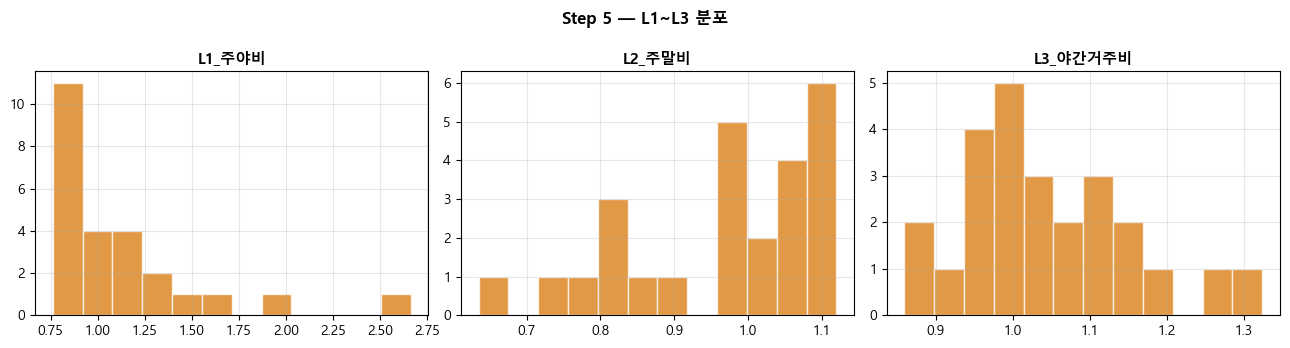

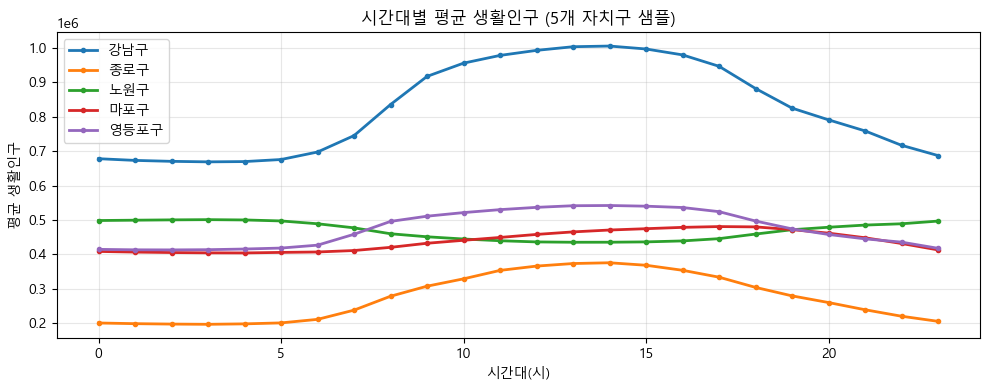

✅ Step 5 검증 통과


In [13]:
print("=== L1~L3 describe ===")
print(lv_var[["L1_주야비", "L2_주말비", "L3_야간거주비"]]
      .describe().round(3))
print()

lv_var_idx = lv_var.set_index("자치구")
print("=== L1 주야비 TOP 5 (중구·종로·강남·영등포 기대) ===")
print(lv_var_idx["L1_주야비"].nlargest(5).round(3))
print()
print("=== L2 주말비 TOP 5 (관광지 — 종로·마포·용산 기대) ===")
print(lv_var_idx["L2_주말비"].nlargest(5).round(3))
print()
print("=== L3 야간거주비 TOP 5 (노원·도봉 등 주거형 기대, 1.0 근처) ===")
print(lv_var_idx["L3_야간거주비"].nlargest(5).round(3))

# L1~L3 히스토그램
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, c in zip(axes, ["L1_주야비", "L2_주말비", "L3_야간거주비"]):
    ax.hist(lv_var[c], bins=12, color="#d97706", alpha=0.75, edgecolor="white")
    ax.set_title(c, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)
plt.suptitle("Step 5 — L1~L3 분포", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 시간대별 평균 인구 — 5개 자치구 비교
sample_gu = ["강남구", "종로구", "노원구", "마포구", "영등포구"]
hourly = (df_lv[df_lv["자치구"].isin(sample_gu)]
          .groupby(["자치구", "tmzon_pd_se"])["tot_lvpop_co"].mean()
          .unstack(0))
fig, ax = plt.subplots(figsize=(10, 4))
for gu in sample_gu:
    ax.plot(hourly.index, hourly[gu], label=gu, linewidth=2, marker="o", markersize=3)
ax.set_xlabel("시간대(시)")
ax.set_ylabel("평균 생활인구")
ax.set_title("시간대별 평균 생활인구 (5개 자치구 샘플)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Step 5 검증 통과")


## Step 6. 데이터 통합 + z-score 표준화

자치구 25행 × 변수 7개 통합 테이블 `gu_features` 생성 후 StandardScaler 적용.

In [14]:
gu_features = (biz_var
    .merge(lv_var[["자치구", "L1_주야비", "L2_주말비", "L3_야간거주비",
                    "거주인구"]], on="자치구")
    .set_index("자치구"))

# 컬럼 정렬
FEATURE_COLS = ["B1_평균규모", "B2_오피스비", "B3_소비관광비", "B4_생활밀착비",
                "L1_주야비", "L2_주말비", "L3_야간거주비"]
gu_features = gu_features[FEATURE_COLS + ["거주인구"]]
print("gu_features shape:", gu_features.shape)
assert gu_features.shape == (25, 8)
assert gu_features[FEATURE_COLS].isna().sum().sum() == 0, "결측 발견"

# z-score
scaler = StandardScaler()
gu_z = pd.DataFrame(
    scaler.fit_transform(gu_features[FEATURE_COLS]),
    columns=FEATURE_COLS,
    index=gu_features.index,
)
print("\ngu_z 평균 (≈0) / std (≈1, ddof=0):")
print(gu_z.agg(["mean", "std"]).round(3))
gu_z.head()


gu_features shape: (25, 8)

gu_z 평균 (≈0) / std (≈1, ddof=0):
      B1_평균규모  B2_오피스비  B3_소비관광비  B4_생활밀착비  L1_주야비  \
mean       -0.000       -0.000         -0.000          0.000     -0.000   
std         1.021        1.021          1.021          1.021      1.021   

      L2_주말비  L3_야간거주비  
mean     -0.000          0.000  
std       1.021          1.021  


,B1_평균규모,B2_오피스비,B3_소비관광비,B4_생활밀착비,L1_주야비,L2_주말비,L3_야간거주비
자치구,,,,,,,
종로구,0.907807,0.812311,0.145385,-0.752888,2.029519,-1.147404,2.572685
중구,1.133617,1.787940,0.338829,-1.608528,3.557079,-2.545950,1.883922
용산구,0.895642,0.846679,2.290679,-0.918875,0.339025,0.124763,0.516730
성동구,0.475340,0.400806,0.051238,-0.830251,0.004972,-0.462993,0.882245
광진구,-0.582213,-0.739516,0.952520,0.428634,-0.481495,0.729990,0.019053


**검증 — Step 6**

mean ≈ 0: True, std (ddof=0) ≈ 1: True

=== 7개 변수 상관관계 ===
               B1_평균규모  B2_오피스비  B3_소비관광비  B4_생활밀착비  \
B1_평균규모           1.00         0.93          -0.34          -0.83   
B2_오피스비           0.93         1.00          -0.38          -0.90   
B3_소비관광비        -0.34        -0.38           1.00           0.28   
B4_생활밀착비        -0.83        -0.90           0.28           1.00   
L1_주야비             0.72         0.76          -0.12          -0.67   
L2_주말비            -0.81        -0.83           0.38           0.70   
L3_야간거주비         0.60         0.51           0.17          -0.41   

               L1_주야비  L2_주말비  L3_야간거주비  
B1_평균규모         0.72      -0.81           0.60  
B2_오피스비         0.76      -0.83           0.51  
B3_소비관광비      -0.12       0.38           0.17  
B4_생활밀착비      -0.67       0.70          -0.41  
L1_주야비           1.00      -0.88           0.74  
L2_주말비          -0.88       1.00          -0.57  
L3_야간거주비       0.74      -0.57           1.00  


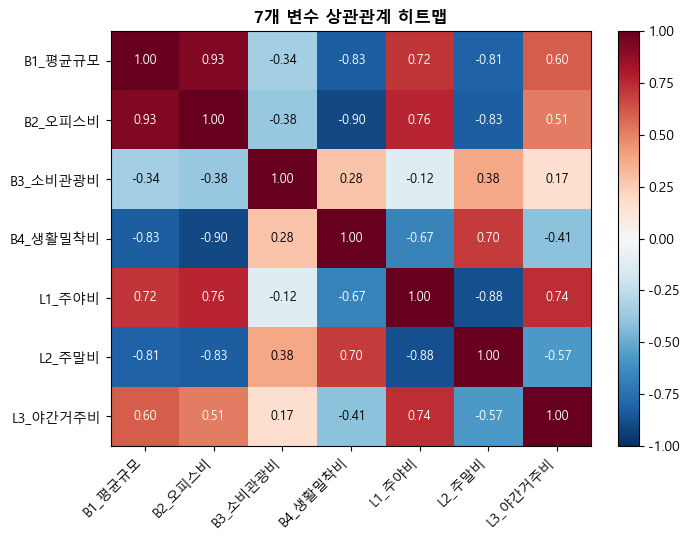

✅ Step 6 검증 통과


In [15]:
# 평균 0, 표준편차 1 검증 (sklearn은 ddof=0)
mean_ok = np.allclose(gu_z.mean(), 0, atol=1e-10)
std_ok  = np.allclose(gu_z.std(ddof=0), 1, atol=1e-10)
print(f"mean ≈ 0: {mean_ok}, std (ddof=0) ≈ 1: {std_ok}")
assert mean_ok and std_ok

print("\n=== 7개 변수 상관관계 ===")
corr = gu_features[FEATURE_COLS].corr()
print(corr.round(2))

# 히트맵
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(7)); ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(FEATURE_COLS)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}",
                ha="center", va="center",
                color="white" if abs(corr.iloc[i,j]) > 0.5 else "black",
                fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("7개 변수 상관관계 히트맵", fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Step 6 검증 통과")


## Step 7. 4유형 분류 적용

z-score 기반 우선순위 분류:
1. **주거형**: `L1 < +0.5σ` AND `B4 > +0.5σ`
2. **상업형**: `B2 > +0.5σ` AND `B1 > +0.5σ` AND `L2 < -0.3σ` (1단계 미할당만)
3. **유동집중형**: `B3 > +0.5σ` AND `L2 > 0σ` (1,2단계 미할당만)
4. **혼합형**: 위 어디에도 해당 안 됨


In [16]:
def classify(z):
    """z: pd.Series — 7개 z-score 값"""
    # 1. 주거형
    if (z["L1_주야비"] < 0.5) and (z["B4_생활밀착비"] > 0.5):
        return "주거형"
    # 2. 상업형
    if (z["B2_오피스비"] > 0.5) and (z["B1_평균규모"] > 0.5) and (z["L2_주말비"] < -0.3):
        return "상업형"
    # 3. 유동집중형
    if (z["B3_소비관광비"] > 0.5) and (z["L2_주말비"] > 0.0):
        return "유동집중형"
    # 4. 혼합형
    return "혼합형"

gu_features["유형"] = gu_z.apply(classify, axis=1)
print(gu_features[["유형"] + FEATURE_COLS[:4]].head())
print("\n=== 유형별 분포 ===")
print(gu_features["유형"].value_counts())


              유형  B1_평균규모  B2_오피스비  B3_소비관광비  B4_생활밀착비
자치구                                                                    
종로구      상업형     5.672325     0.307603       0.270190       0.158138
중구        상업형     5.960833     0.410461       0.276900       0.074487
용산구  유동집중형     5.656782     0.311226       0.344603       0.141911
성동구      혼합형     5.119779     0.264219       0.266925       0.150575
광진구  유동집중형     3.768584     0.143997       0.298187       0.273648

=== 유형별 분포 ===
유형
주거형        10
상업형         6
혼합형         6
유동집중형     3
Name: count, dtype: int64


**검증 — Step 7**

In [17]:
assert gu_features["유형"].isna().sum() == 0
print("4유형 분포:")
print(gu_features["유형"].value_counts())
print()
for t in ["주거형", "상업형", "유동집중형", "혼합형"]:
    members = gu_features[gu_features["유형"] == t].index.tolist()
    print(f"[{t}] {len(members)}개 — {', '.join(members) if members else '(없음)'}")

# 직관 검증 (예상 자치구가 어떤 유형으로 갔는지)
print()
print("=== 직관 검증 ===")
expected = {
    "주거형 후보":   ["노원구", "도봉구", "강북구", "중랑구"],
    "상업형 후보":   ["강남구", "서초구", "영등포구"],
    "유동집중형 후보": ["종로구", "중구"],
    "혼합형 후보":   ["마포구", "동작구", "광진구"],
}
for label, gus in expected.items():
    for gu in gus:
        if gu in gu_features.index:
            print(f"  {gu:6s} → 실제: {gu_features.loc[gu, '유형']:6s}  (기대: {label})")
print("\n✅ Step 7 검증 통과")


4유형 분포:
유형
주거형        10
상업형         6
혼합형         6
유동집중형     3
Name: count, dtype: int64

[주거형] 10개 — 동대문구, 성북구, 강북구, 도봉구, 노원구, 은평구, 서대문구, 양천구, 동작구, 관악구
[상업형] 6개 — 종로구, 중구, 금천구, 영등포구, 서초구, 강남구
[유동집중형] 3개 — 용산구, 광진구, 송파구
[혼합형] 6개 — 성동구, 중랑구, 마포구, 강서구, 구로구, 강동구

=== 직관 검증 ===
  노원구    → 실제: 주거형     (기대: 주거형 후보)
  도봉구    → 실제: 주거형     (기대: 주거형 후보)
  강북구    → 실제: 주거형     (기대: 주거형 후보)
  중랑구    → 실제: 혼합형     (기대: 주거형 후보)
  강남구    → 실제: 상업형     (기대: 상업형 후보)
  서초구    → 실제: 상업형     (기대: 상업형 후보)
  영등포구   → 실제: 상업형     (기대: 상업형 후보)
  종로구    → 실제: 상업형     (기대: 유동집중형 후보)
  중구     → 실제: 상업형     (기대: 유동집중형 후보)
  마포구    → 실제: 혼합형     (기대: 혼합형 후보)
  동작구    → 실제: 주거형     (기대: 혼합형 후보)
  광진구    → 실제: 유동집중형   (기대: 혼합형 후보)

✅ Step 7 검증 통과


## Step 8. KMeans 사이드 체크

KMeans(k=4)는 라벨 번호가 의미 없으므로 클러스터→유형 매핑은 **다수결**로 결정한 뒤 일치율을 계산.

### 🔧 KMeans 호환성 패치

Anaconda 일부 환경의 `threadpoolctl 2.x` 구버전이 OpenBLAS 설정을 읽다 `AttributeError`를 일으킴. KMeans 내부의 `_check_mkl_vcomp` 메서드(MKL/OpenMP 충돌 검사용 — 결과 계산과 무관)를 빈 함수로 교체해 그 호출을 우회함.

- 25개 자치구 클러스터링은 단일 스레드로 끝나므로 BLAS 검사 자체가 의미 없음
- 클러스터링 결과 수치에는 영향 없음 (환경 경고만 안 뜸)
- threadpoolctl을 업그레이드하면 이 패치는 불필요

In [18]:
import sklearn.cluster._kmeans as _km
_km._BaseKMeans._check_mkl_vcomp = lambda self, X, n_samples: None
print("✅ KMeans BLAS 검사 우회 활성화 (threadpoolctl 구버전 호환)")


✅ KMeans BLAS 검사 우회 활성화 (threadpoolctl 구버전 호환)


In [19]:
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(gu_z)
gu_features["kmeans_label"] = km.labels_
print("KMeans 라벨 분포:")
print(pd.Series(km.labels_).value_counts().sort_index())
print()

# 클러스터 → 유형 매핑 (각 클러스터에서 가장 많은 도메인 라벨)
cross = pd.crosstab(gu_features["kmeans_label"], gu_features["유형"])
print("=== 교차표 ===")
print(cross)
print()
cluster_to_type = cross.idxmax(axis=1).to_dict()
print("클러스터→유형 매핑(다수결):", cluster_to_type)

gu_features["kmeans_유형"] = gu_features["kmeans_label"].map(cluster_to_type)
agree = (gu_features["유형"] == gu_features["kmeans_유형"]).mean()
print(f"\n일치율: {agree*100:.1f}%")

mismatch = gu_features[gu_features["유형"] != gu_features["kmeans_유형"]]
print(f"\n불일치 자치구 ({len(mismatch)}개):")
if len(mismatch):
    print(mismatch[["유형", "kmeans_label", "kmeans_유형"]])


KMeans 라벨 분포:
0    13
1     3
2     6
3     3
Name: count, dtype: int64

=== 교차표 ===
유형          상업형  유동집중형  주거형  혼합형
kmeans_label                                    
0                  0           1      10       2
1                  3           0       0       0
2                  0           2       0       4
3                  3           0       0       0

클러스터→유형 매핑(다수결): {0: '주거형', 1: '상업형', 2: '혼합형', 3: '상업형'}

일치율: 80.0%

불일치 자치구 (5개):
              유형  kmeans_label kmeans_유형
자치구                                      
용산구  유동집중형             2      혼합형
광진구  유동집중형             0      주거형
중랑구      혼합형             0      주거형
송파구  유동집중형             2      혼합형
강동구      혼합형             0      주거형


In [20]:
import threadpoolctl, sys
print("Python   :", sys.executable)
print("로드 위치:", threadpoolctl.__file__)
print("버전     :", getattr(threadpoolctl, '__version__', '없음'))


Python   : c:\Users\windows\anaconda3\python.exe
로드 위치: c:\Users\windows\anaconda3\Lib\site-packages\threadpoolctl.py
버전     : 3.5.0


**검증 — Step 8**

In [21]:
agree = (gu_features["유형"] == gu_features["kmeans_유형"]).mean()
print(f"일치율: {agree*100:.1f}%")
if agree < 0.7:
    print("⚠️  일치율 70% 미만 — 도메인 규칙 임계치 재검토 필요")
else:
    print("✅ 일치율 70% 이상 — 도메인 분류와 KMeans 일관성 확보")

# 두 분류 결과를 한 표로
side = gu_features[["유형", "kmeans_label", "kmeans_유형"]].copy()
side["일치"] = np.where(side["유형"] == side["kmeans_유형"], "✓", "✗")
print()
print("=== 자치구별 두 분류 결과 ===")
print(side.sort_values(["유형", "kmeans_유형"]))


일치율: 80.0%
✅ 일치율 70% 이상 — 도메인 분류와 KMeans 일관성 확보

=== 자치구별 두 분류 결과 ===
                유형  kmeans_label kmeans_유형 일치
자치구                                             
종로구        상업형             1      상업형    ✓
중구          상업형             1      상업형    ✓
금천구        상업형             3      상업형    ✓
영등포구      상업형             3      상업형    ✓
서초구        상업형             3      상업형    ✓
강남구        상업형             1      상업형    ✓
광진구    유동집중형             0      주거형    ✗
용산구    유동집중형             2      혼합형    ✗
송파구    유동집중형             2      혼합형    ✗
동대문구      주거형             0      주거형    ✓
성북구        주거형             0      주거형    ✓
강북구        주거형             0      주거형    ✓
도봉구        주거형             0      주거형    ✓
노원구        주거형             0      주거형    ✓
은평구        주거형             0      주거형    ✓
서대문구      주거형             0      주거형    ✓
양천구        주거형             0      주거형    ✓
동작구        주거형             0      주거형    ✓
관악구        주거형             0      주거형    ✓
중랑구        혼합형            

## Step 9. 결과 저장 + 시각화

`data/preprocess/gu_classified.csv`로 저장. 컬럼: `자치구, 거주인구, B1~B4, L1~L3, 유형, kmeans_label`.

추가로 사분면 산점도(B2 z-score × L2 z-score)로 4유형 분포 확인.

In [22]:
out_cols = ["거주인구",
            "B1_평균규모", "B2_오피스비", "B3_소비관광비", "B4_생활밀착비",
            "L1_주야비", "L2_주말비", "L3_야간거주비",
            "유형", "kmeans_label"]
out_path = os.path.join(PREPROC_DIR, "gu_classified.csv")
gu_features[out_cols].to_csv(out_path, encoding="utf-8-sig",
                              index=True, index_label="자치구")
print(f"✅ 저장 완료: {out_path}")
print(f"   ({os.path.getsize(out_path):,} bytes)")

# 콘솔에 4유형별 명단
print()
print("="*60)
print("  4유형별 자치구 명단")
print("="*60)
for t in ["주거형", "상업형", "유동집중형", "혼합형"]:
    members = gu_features[gu_features["유형"] == t].index.tolist()
    print(f"\n  🏷  {t} ({len(members)}개)")
    print(f"     {' · '.join(members) if members else '(없음)'}")


✅ 저장 완료: d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess\gu_classified.csv
   (3,829 bytes)

  4유형별 자치구 명단

  🏷  주거형 (10개)
     동대문구 · 성북구 · 강북구 · 도봉구 · 노원구 · 은평구 · 서대문구 · 양천구 · 동작구 · 관악구

  🏷  상업형 (6개)
     종로구 · 중구 · 금천구 · 영등포구 · 서초구 · 강남구

  🏷  유동집중형 (3개)
     용산구 · 광진구 · 송파구

  🏷  혼합형 (6개)
     성동구 · 중랑구 · 마포구 · 강서구 · 구로구 · 강동구


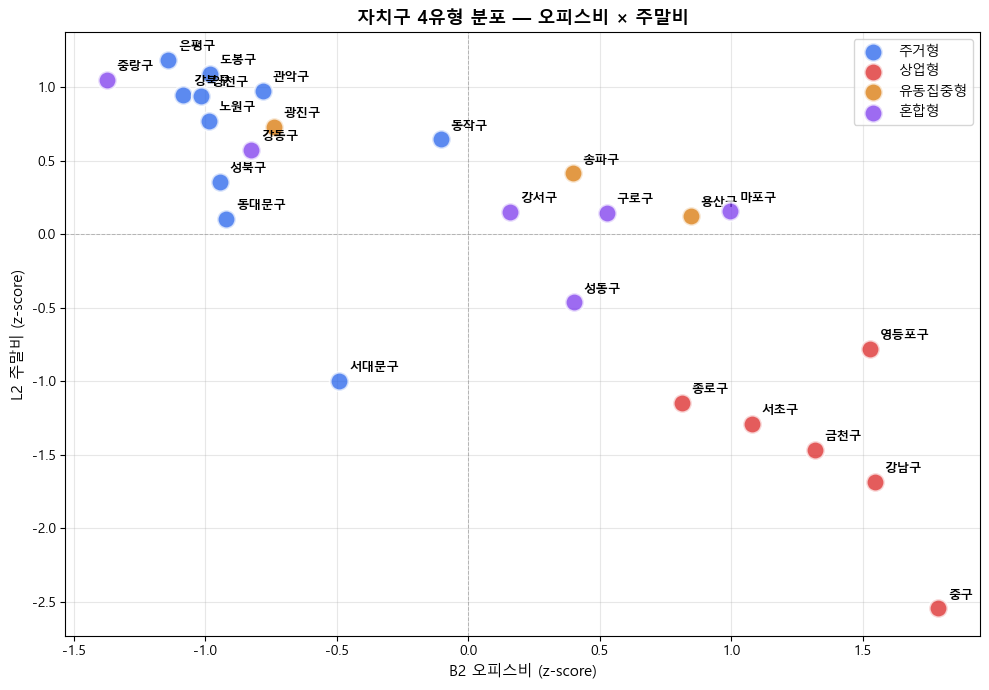

In [23]:
# 사분면 산점도: x=B2 z, y=L2 z, 색=유형
TYPE_COLOR = {"주거형": "#2563eb", "상업형": "#dc2626",
              "유동집중형": "#d97706", "혼합형": "#7c3aed"}

fig, ax = plt.subplots(figsize=(10, 7))
for t, color in TYPE_COLOR.items():
    members = gu_features[gu_features["유형"] == t].index
    if len(members) == 0:
        continue
    xs = gu_z.loc[members, "B2_오피스비"]
    ys = gu_z.loc[members, "L2_주말비"]
    ax.scatter(xs, ys, c=color, s=180, alpha=0.75, label=t,
               edgecolor="white", linewidth=2, zorder=3)
    for gu_name, x, y in zip(members, xs, ys):
        ax.annotate(gu_name, (x, y), fontsize=9, fontweight="bold",
                    xytext=(7, 7), textcoords="offset points")

ax.axhline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
ax.set_xlabel("B2 오피스비 (z-score)", fontsize=11)
ax.set_ylabel("L2 주말비 (z-score)", fontsize=11)
ax.set_title("자치구 4유형 분포 — 오피스비 × 주말비",
             fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10, frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**검증 — Step 9**

In [24]:
# 저장된 CSV 다시 읽어 검증
saved = pd.read_csv(out_path, encoding="utf-8-sig")
print("저장된 shape:", saved.shape)
print("컬럼:", saved.columns.tolist())
print()
print(saved.head())
print()
print("유형별 합:", saved["유형"].value_counts().to_dict())
assert len(saved) == 25
assert saved["유형"].value_counts().sum() == 25
assert set(saved["유형"].unique()).issubset(
    {"주거형", "상업형", "유동집중형", "혼합형"})
print("\n🎉 모든 Step 완료 — gu_classified.csv 생성됨")


저장된 shape: (25, 11)
컬럼: ['자치구', '거주인구', 'B1_평균규모', 'B2_오피스비', 'B3_소비관광비', 'B4_생활밀착비', 'L1_주야비', 'L2_주말비', 'L3_야간거주비', '유형', 'kmeans_label']

   자치구  거주인구  B1_평균규모  B2_오피스비  B3_소비관광비  B4_생활밀착비  \
0  종로구    149608     5.672325     0.307603       0.270190       0.158138   
1    중구    131214     5.960833     0.410461       0.276900       0.074487   
2  용산구    217194     5.656782     0.311226       0.344603       0.141911   
3  성동구    281289     5.119779     0.264219       0.266925       0.150575   
4  광진구    348652     3.768584     0.143997       0.298187       0.273648   

   L1_주야비  L2_주말비  L3_야간거주비        유형  kmeans_label  
0   2.002263   0.816489       1.323396      상업형             1  
1   2.663637   0.634760       1.249486      상업형             1  
2   1.270344   0.981797       1.102776  유동집중형             2  
3   1.125712   0.905423       1.141999      혼합형             2  
4   0.915091   1.060441       1.049371  유동집중형             0  

유형별 합: {'주거형': 10, '상업형': 6, '혼합형': 6, '유동집중형': 3}

